# TTC Subway Delay Predictor — Data EDA

Pure exploration of the raw incident dataset — no model-specific feature
engineering here (no `model.features` import). The goal is to understand
the data on its own terms: distributions, categorical breakdowns,
temporal patterns, and weather relationships.

For how these patterns translate into modeling decisions (which features
get engineered, why one got cut, what the production model achieves, and
which alternative architectures were tried and rejected), see
**`02_model_evaluation.ipynb`** — it picks up exactly where this notebook
leaves off.

**Sections**
1. Setup
2. Target Variable Analysis
3. Feature–Target Relationships (codes, lines/stations, temporal, weather)
4. Summary of Data Patterns

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Deliberately only the raw-data query and a lookup table -- nothing from
# model/ or services/. This notebook explores the data as it exists in the
# database, independent of any modeling choices made on top of it.
from database.queries import get_code_descriptions, get_raw_incident_level_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("Setup complete.")

Setup complete.


In [2]:
# Plot styling: fixed categorical palette (colorblind-safe order), single-hue
# sequential ramp for magnitude, blue<->red diverging pair for correlations.
CATEGORICAL_PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
DIVERGING_CMAP = sns.diverging_palette(255, 10, s=75, l=45, sep=10, as_cmap=True)
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.style.use("seaborn-v0_8")
sns.set_palette(CATEGORICAL_PALETTE)
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID_COLOR,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "font.size": 10.5,
        "figure.dpi": 100,
        "savefig.dpi": 130,
    }
)
print("Styling configured.")

Styling configured.


In [3]:
df = get_raw_incident_level_data()
df["date"] = pd.to_datetime(df["date"])
TARGET_COLUMN = "min_delay"
print(f"Raw incident rows: {len(df):,}")
print(f"Date range: {df['date'].min().date()} \u2192 {df['date'].max().date()}")
df.head()

Raw incident rows: 87,421
Date range: 2014-01-01 → 2026-06-30


,date,hour,line,station,bound,code,description,min_delay,temp_c,precipitation_mm,snow_depth_mm,wind_speed_kmh
0,2014-01-01,0,Line 2 (Bloor-Danforth),VICTORIA PARK STATION,W,MUPR1,Priority One - Train in Contact With Person,55,-9.3375,0.0,80.0,18.0144
1,2014-01-01,2,Line 2 (Bloor-Danforth),HIGH PARK STATION,W,SUDP,Disorderly Patron,3,-9.6875,0.0,80.0,16.9544
2,2014-01-01,3,Line 2 (Bloor-Danforth),LANSDOWNE STATION,W,SUDP,Disorderly Patron,3,-9.9375,0.0,80.0,15.8564
3,2014-01-01,3,Line 1 (Yonge-University),BLOOR-YONGE STATION,S,MUSAN,Unsanitary Vehicle,5,-9.9375,0.0,80.0,15.8564
4,2014-01-01,8,Line 2 (Bloor-Danforth),KIPLING STATION,E,MUNOA,No Operator Immediately Available - Not E.S.A....,5,-11.2875,0.0,80.0,12.5743


## 2. Target Variable Analysis

In [4]:
target = df[TARGET_COLUMN]
summary = pd.Series(
    {
        "count": len(target),
        "mean": target.mean(),
        "median": target.median(),
        "std": target.std(),
        "min": target.min(),
        "max": target.max(),
        "p90": target.quantile(0.90),
        "p95": target.quantile(0.95),
        "p99": target.quantile(0.99),
        "pct_over_60min": (target > 60).mean() * 100,
        "skew_raw": target.skew(),
        "skew_log1p": np.log1p(target).skew(),
    }
).round(2)
summary.to_frame("min_delay")

,min_delay
count,87421.00
mean,7.19
median,4.00
std,14.65
min,1.00
max,900.00
p90,12.00
p95,18.00
p99,45.00
pct_over_60min,0.68


`min_delay` is heavily right-skewed — mean (7.2) is nearly double
the median (4.0), and skew drops from ~23 on the raw scale to ~2 on a
log1p scale. (This is exactly the property `02_model_evaluation.ipynb`
uses to justify training on `log1p(min_delay)`.)

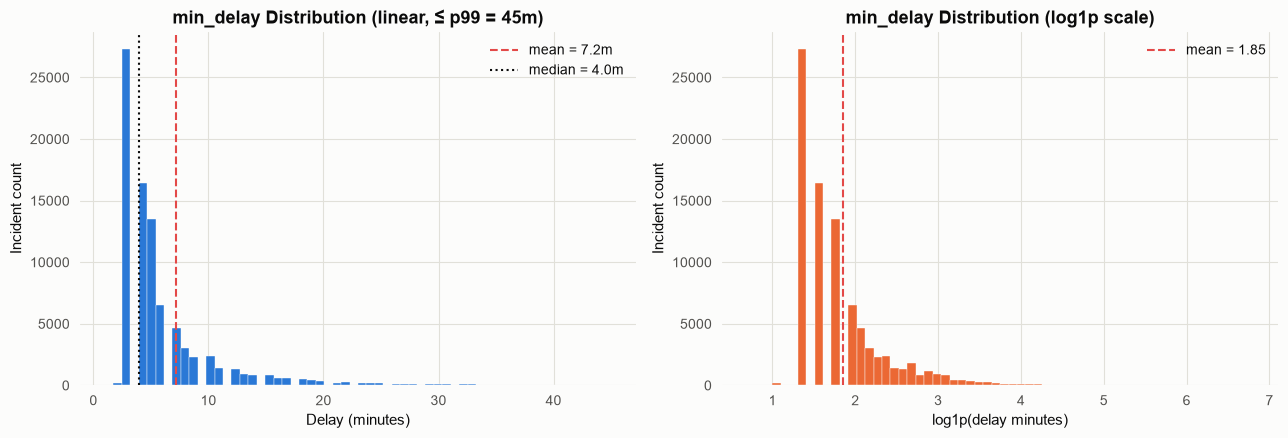

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
clip_val = target.quantile(0.99)
axes[0].hist(
    target[target <= clip_val],
    bins=60,
    color=CATEGORICAL_PALETTE[0],
    edgecolor=SURFACE,
    linewidth=0.3,
)
axes[0].axvline(
    target.mean(),
    color=CATEGORICAL_PALETTE[7],
    linestyle="--",
    linewidth=1.5,
    label=f"mean = {target.mean():.1f}m",
)
axes[0].axvline(
    target.median(),
    color=INK,
    linestyle=":",
    linewidth=1.5,
    label=f"median = {target.median():.1f}m",
)
axes[0].set_title(f"min_delay Distribution (linear, \u2264 p99 = {clip_val:.0f}m)")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Incident count")
axes[0].legend(frameon=False)

log_target = np.log1p(target)
axes[1].hist(log_target, bins=60, color=CATEGORICAL_PALETTE[1], edgecolor=SURFACE, linewidth=0.3)
axes[1].axvline(
    log_target.mean(),
    color=CATEGORICAL_PALETTE[7],
    linestyle="--",
    linewidth=1.5,
    label=f"mean = {log_target.mean():.2f}",
)
axes[1].set_title("min_delay Distribution (log1p scale)")
axes[1].set_xlabel("log1p(delay minutes)")
axes[1].set_ylabel("Incident count")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Feature–Target Relationships

### 3.1 Incident Codes

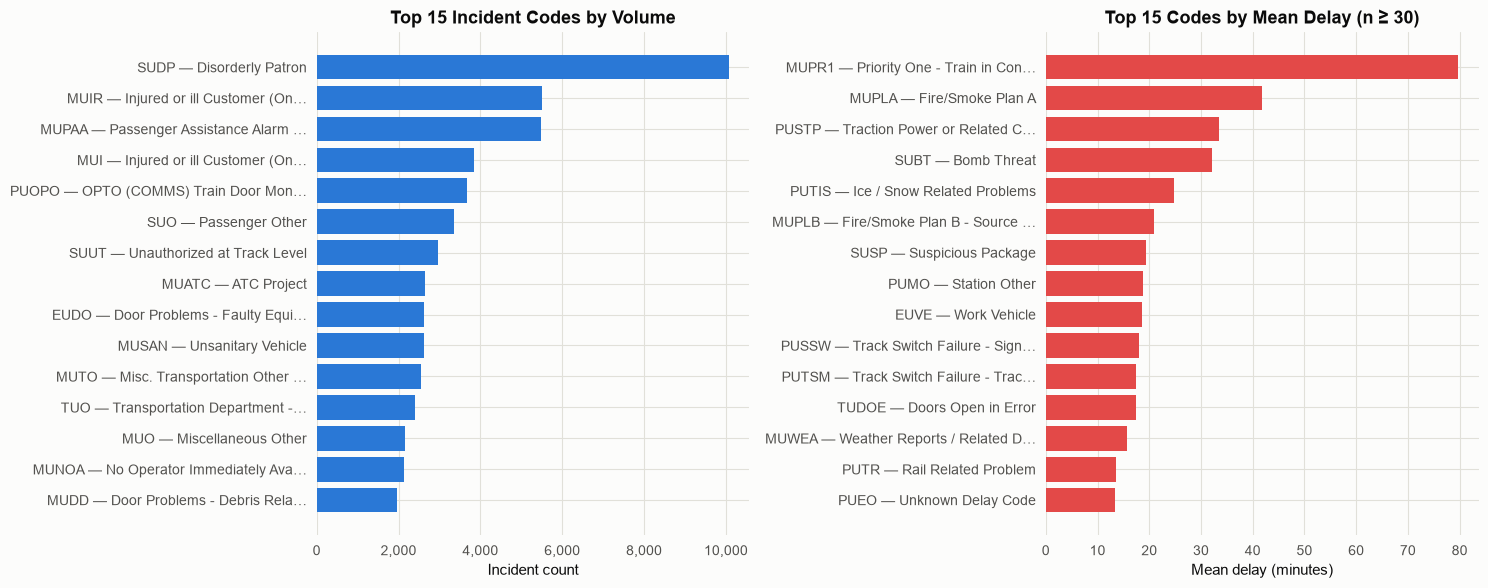

Top 15 by volume:


,n_incidents,mean_delay,median_delay,description
code,,,,
SUDP,10069,6.3,5.0,Disorderly Patron
MUIR,5502,6.1,5.0,Injured or ill Customer (On Train) - Medical A...
MUPAA,5481,3.9,3.0,Passenger Assistance Alarm Activated - No Trou...
MUI,3854,9.9,7.0,Injured or ill Customer (On Train) - Transported
PUOPO,3664,5.2,4.0,OPTO (COMMS) Train Door Monitoring
SUO,3353,8.7,5.0,Passenger Other
SUUT,2952,12.9,9.0,Unauthorized at Track Level
MUATC,2640,6.0,5.0,ATC Project
EUDO,2624,5.5,5.0,Door Problems - Faulty Equipment



Top 15 by mean delay (n ≥ 30):


,n_incidents,mean_delay,median_delay,description
code,,,,
MUPR1,385,79.7,77.0,Priority One - Train in Contact With Person
MUPLA,41,41.8,11.0,Fire/Smoke Plan A
PUSTP,44,33.5,10.0,Traction Power or Related Components Failure
SUBT,114,32.1,23.5,Bomb Threat
PUTIS,203,24.7,4.0,Ice / Snow Related Problems
MUPLB,1209,20.9,14.0,Fire/Smoke Plan B - Source TTC
SUSP,100,19.4,8.0,Suspicious Package
PUMO,82,18.7,5.5,Station Other
EUVE,214,18.6,8.0,Work Vehicle


In [6]:
code_descriptions = get_code_descriptions()
code_stats = (
    df.groupby("code")[TARGET_COLUMN]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "n_incidents", "mean": "mean_delay", "median": "median_delay"})
)
code_stats["description"] = code_stats.index.map(code_descriptions)

MIN_CODE_COUNT = 30
top15_volume = code_stats.sort_values("n_incidents", ascending=False).head(15)
top15_severity = (
    code_stats[code_stats["n_incidents"] >= MIN_CODE_COUNT]
    .sort_values("mean_delay", ascending=False)
    .head(15)
)


def _label(idx, desc, max_len=28):
    d = (
        desc
        if isinstance(desc, str) and len(desc) <= max_len
        else (str(desc)[: max_len - 1] + "\u2026" if isinstance(desc, str) else "")
    )
    return f"{idx} \u2014 {d}" if d else str(idx)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(
    [_label(i, d) for i, d in zip(top15_volume.index, top15_volume["description"], strict=False)][
        ::-1
    ],
    top15_volume["n_incidents"][::-1],
    color=CATEGORICAL_PALETTE[0],
)
axes[0].set_title("Top 15 Incident Codes by Volume")
axes[0].set_xlabel("Incident count")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

axes[1].barh(
    [
        _label(i, d)
        for i, d in zip(top15_severity.index, top15_severity["description"], strict=False)
    ][::-1],
    top15_severity["mean_delay"][::-1],
    color=CATEGORICAL_PALETTE[7],
)
axes[1].set_title(f"Top 15 Codes by Mean Delay (n \u2265 {MIN_CODE_COUNT})")
axes[1].set_xlabel("Mean delay (minutes)")
plt.tight_layout()
plt.show()

print("Top 15 by volume:")
display(top15_volume.round(1))
print(f"\nTop 15 by mean delay (n \u2265 {MIN_CODE_COUNT}):")
display(top15_severity.round(1))

Frequency and severity rank completely differently. The
highest-volume codes (patron/medical incidents) are all short. The
highest-severity codes are rare safety events. Different operational
problems, worth treating as such.

### 3.2 Line & Station Analysis

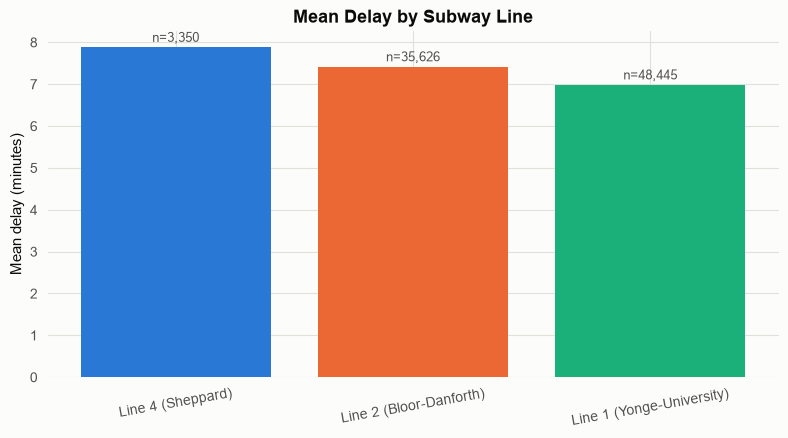

,n_incidents,mean_delay,median_delay
line,,,
Line 4 (Sheppard),3350,7.88,5.0
Line 2 (Bloor-Danforth),35626,7.41,4.0
Line 1 (Yonge-University),48445,6.98,4.0


In [7]:
line_stats = (
    df.groupby("line")[TARGET_COLUMN]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "n_incidents", "mean": "mean_delay", "median": "median_delay"})
    .sort_values("mean_delay", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(
    line_stats.index, line_stats["mean_delay"], color=CATEGORICAL_PALETTE[: len(line_stats)]
)
for bar, n in zip(bars, line_stats["n_incidents"], strict=False):
    ax.annotate(
        f"n={n:,}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=9,
        color=INK_SECONDARY,
    )
ax.set_title("Mean Delay by Subway Line")
ax.set_ylabel("Mean delay (minutes)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()
display(line_stats.round(2))

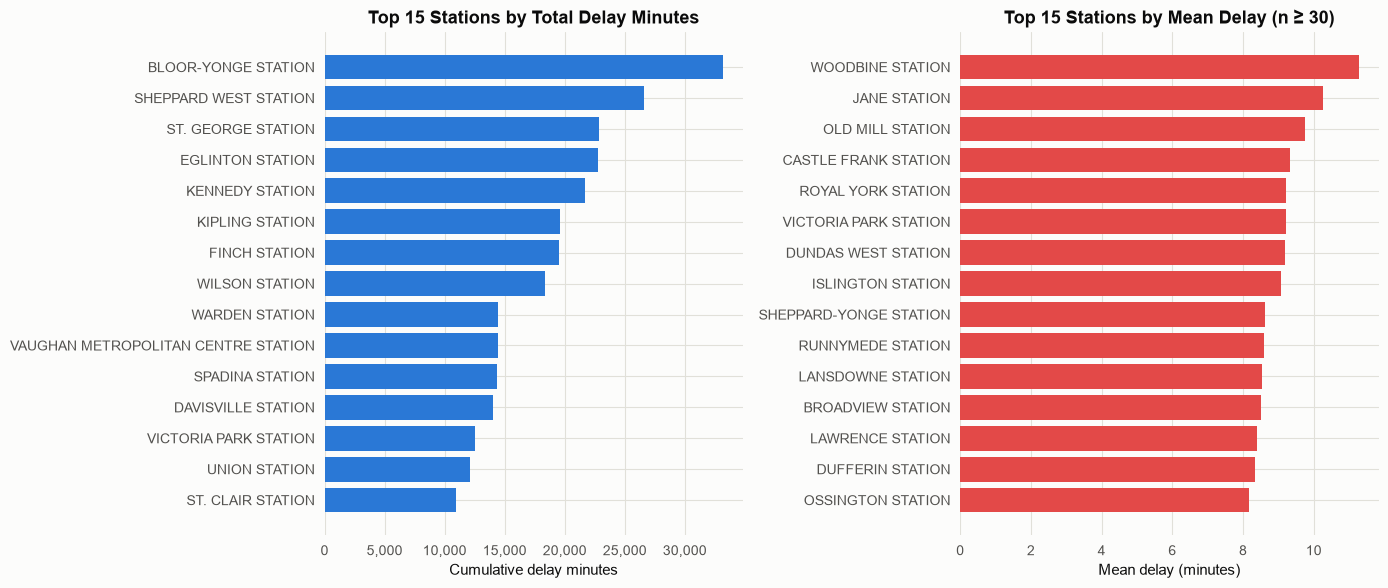

In [8]:
station_stats = (
    df.groupby("station")[TARGET_COLUMN]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "n_incidents", "sum": "total_delay_minutes", "mean": "mean_delay"})
)
top15_total = station_stats.sort_values("total_delay_minutes", ascending=False).head(15)
top15_mean = (
    station_stats[station_stats["n_incidents"] >= MIN_CODE_COUNT]
    .sort_values("mean_delay", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(
    top15_total.index[::-1], top15_total["total_delay_minutes"][::-1], color=CATEGORICAL_PALETTE[0]
)
axes[0].set_title("Top 15 Stations by Total Delay Minutes")
axes[0].set_xlabel("Cumulative delay minutes")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
axes[1].barh(top15_mean.index[::-1], top15_mean["mean_delay"][::-1], color=CATEGORICAL_PALETTE[7])
axes[1].set_title(f"Top 15 Stations by Mean Delay (n \u2265 {MIN_CODE_COUNT})")
axes[1].set_xlabel("Mean delay (minutes)")
plt.tight_layout()
plt.show()

### 3.3 Temporal Trends

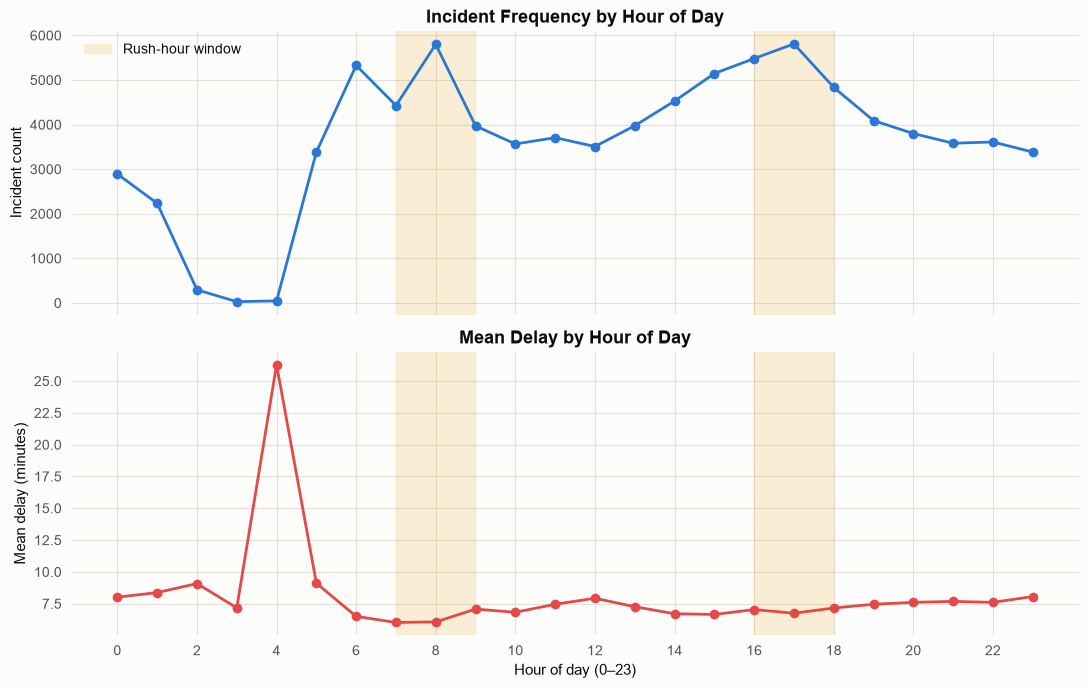

,n_incidents,mean_delay
rush_hour_window,,
Off-peak,63176,7.51
Peak,24245,6.35


In [9]:
hourly_stats = (
    df.groupby("hour")[TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_incidents", "mean": "mean_delay"})
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(
    hourly_stats.index,
    hourly_stats["n_incidents"],
    marker="o",
    color=CATEGORICAL_PALETTE[0],
    linewidth=2,
)
axes[0].set_title("Incident Frequency by Hour of Day")
axes[0].set_ylabel("Incident count")
axes[1].plot(
    hourly_stats.index,
    hourly_stats["mean_delay"],
    marker="o",
    color=CATEGORICAL_PALETTE[7],
    linewidth=2,
)
axes[1].set_title("Mean Delay by Hour of Day")
axes[1].set_xlabel("Hour of day (0\u201323)")
axes[1].set_ylabel("Mean delay (minutes)")
axes[1].set_xticks(range(0, 24, 2))
for ax in axes:
    ax.axvspan(7, 9, color=CATEGORICAL_PALETTE[3], alpha=0.15, label="Rush-hour window")
    ax.axvspan(16, 18, color=CATEGORICAL_PALETTE[3], alpha=0.15)
axes[0].legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

# A simple weekday-rush-hour cut, computed here for exploration only -- not
# an import of the model's engineered is_peak_hour feature, though the
# underlying logic is the same natural grouping.
is_weekday = ~df["date"].dt.day_name().isin(["Saturday", "Sunday"])
is_rush = df["hour"].between(7, 9) | df["hour"].between(16, 18)
df["rush_hour_window"] = is_weekday & is_rush

window_stats = (
    df.groupby("rush_hour_window")[TARGET_COLUMN]
    .agg(["count", "mean"])
    .rename(
        index={False: "Off-peak", True: "Peak"},
        columns={"count": "n_incidents", "mean": "mean_delay"},
    )
)
display(window_stats.round(2))

**Off-peak incidents run longer than peak-hour ones**, the
opposite of what ridership pressure alone would predict — likely denser
crew/train coverage at peak means faster recovery.

### 3.4 Weather Impact

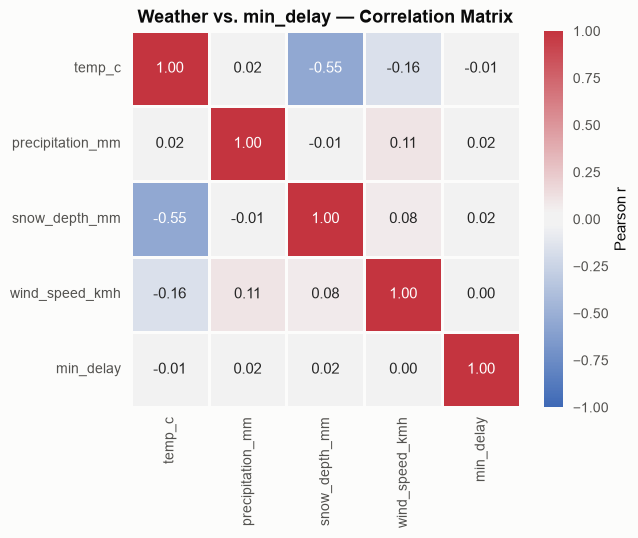

,pearson_r
snow_depth_mm,0.024
precipitation_mm,0.016
wind_speed_kmh,0.005
temp_c,-0.013


In [10]:
weather_cols = ["temp_c", "precipitation_mm", "snow_depth_mm", "wind_speed_kmh"]
corr = df[[*weather_cols, TARGET_COLUMN]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=1,
    linecolor=SURFACE,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Weather vs. min_delay \u2014 Correlation Matrix")
plt.tight_layout()
plt.show()
display(
    corr[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(ascending=False)
    .round(3)
    .to_frame("pearson_r")
)

Every weather variable correlates with `min_delay` at |r| ≤ 0.032
— see `02_model_evaluation.ipynb` for how this (and the model's own
feature importances) shapes how much the deployed API actually invests
in weather data.

## 4. Summary of Data Patterns

- **87,421 incidents**, 2014-01-01 → present, across 3 lines / 70 stations / 138 codes.
- `min_delay` is heavily right-skewed (raw skew ~23, mean 7.2m vs. median 4.0m).
- Frequency and severity are nearly unrelated — the highest-volume code (`SUDP`, Disorderly Patron) averages 6.3 minutes; the highest-severity code (`MUPR1`, Priority One) averages 79.7 minutes over just 385 incidents.
- Off-peak incidents run longer than peak ones on average (7.51m vs. 6.35m) — counter to a naive "busier = worse" assumption.
- Weather shows essentially no linear relationship with individual incident duration (|r| ≤ 0.032 for every variable).

These four patterns are the direct inputs to every modeling decision documented in **`02_model_evaluation.ipynb`**.